In [2]:
from PIL import Image, ImageFilter
import numpy as np
import matplotlib.pyplot as plt
import math
import sys
from sklearn.cluster import KMeans
from scipy.signal import find_peaks
from collections import Counter

In [3]:
def to_gray(img_arr):
    if img_arr.ndim == 2:
        return img_arr.astype(np.float32) / 255.0
    r, g, b = img_arr[..., 0], img_arr[..., 1], img_arr[..., 2]
    gray = 0.299 * r + 0.587 * g + 0.114 * b
    return gray.astype(np.float32) / 255.0

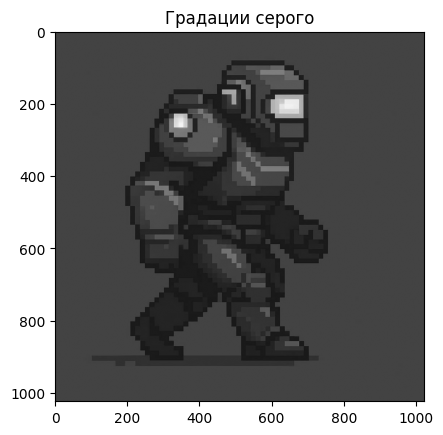

In [4]:

img = np.array(Image.open("robot.jpg").convert("RGB"))
gray = to_gray(img)

plt.imshow(gray, cmap="gray")
plt.show()

In [5]:
def sobel_gradients(gray):
    Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    Ky = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=np.float32)
    from scipy.signal import convolve2d
    gx = convolve2d(gray, Kx, mode='same', boundary='symm')
    gy = convolve2d(gray, Ky, mode='same', boundary='symm')
    return np.abs(gx), np.abs(gy)

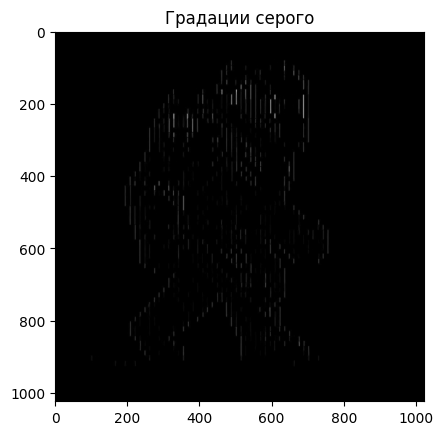

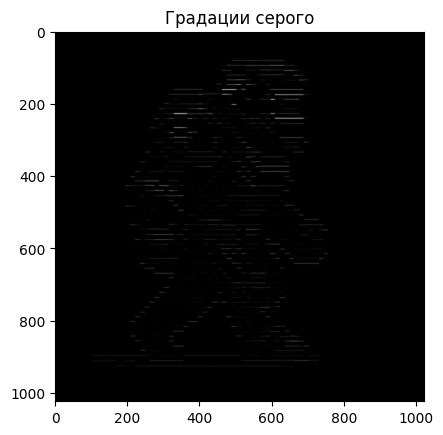

In [6]:
gx, gy = sobel_gradients(gray)
plt.imshow(gx, cmap="gray")
plt.show()
plt.imshow(gy, cmap="gray")
plt.show()

In [7]:
def profile_from_gradients(gx, gy):
    """Строим по X и Y: суммируем градиенты по столбцам и строкам"""
    profile_x = np.sum(gx, axis=0)  # сумма по строкам => горизонтальные пики
    profile_y = np.sum(gy, axis=1)  # сумма по столбцам => вертикальные пики
    return profile_x, profile_y

In [8]:
def estimate_scale_fft(profile):
    profile = profile - np.mean(profile)
    fft_vals = np.fft.fft(profile)
    fft_freq = np.fft.fftfreq(len(profile))
    # игнорируем нулевую частоту
    fft_vals[0] = 0
    # индекс максимальной амплитуды
    idx = np.argmax(np.abs(fft_vals))
    scale = int(len(profile) / idx)
    return scale



In [9]:
gx, gy = sobel_gradients(gray)
profile_x, profile_y = profile_from_gradients(gx, gy)

scale_x = estimate_scale_fft(profile_x)
scale_y = estimate_scale_fft(profile_y)
print(f"Оценка масштаба: по X = {scale_x}, по Y = {scale_y}")

Оценка масштаба: по X = 13, по Y = 13


In [10]:
def find_best_offset(profile, scale):
    best_offset = 0
    max_score = -1
    for offset in range(scale):
        score = np.sum(profile[offset::scale])
        if score > max_score:
            max_score = score
            best_offset = offset
    return best_offset

In [11]:
def find_optimal_crop(gray, scale):
    gx, gy = sobel_gradients(gray)
    profile_x, profile_y = profile_from_gradients(gx, gy)
    best_dx = find_best_offset(profile_x, scale)
    best_dy = find_best_offset(profile_y, scale)
    print(f"Optimal crop found: x={best_dx}, y={best_dy}")
    return best_dx, best_dy

In [12]:
def find_optimal_crop(gray, scale):
    gx, gy = sobel_gradients(gray)
    profile_x, profile_y = profile_from_gradients(gx, gy)
    best_dx = find_best_offset(profile_x, scale)
    best_dy = find_best_offset(profile_y, scale)
    print(f"Optimal crop found: x={best_dx}, y={best_dy}")
    return best_dx, best_dy

In [13]:
best_dx = find_best_offset(profile_x, scale_x)
best_dy = find_best_offset(profile_y, scale_y)
print(f"Лучший сдвиг сетки: x={best_dx}, y={best_dy}")

Лучший сдвиг сетки: x=11, y=7


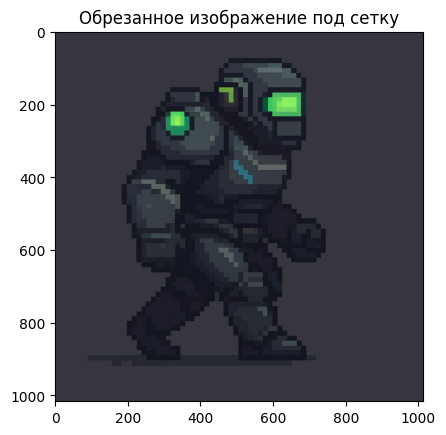

In [14]:
def crop_to_scale(img, best_dx, best_dy, scale_x, scale_y):
    h, w = img.shape[:2]
    new_w = w - (w - best_dx) % scale_x
    new_h = h - (h - best_dy) % scale_y
    return img[best_dy:best_dy+new_h, best_dx:best_dx+new_w]

cropped_img = crop_to_scale(img, best_dx, best_dy, scale_x, scale_y)
plt.imshow(cropped_img)
plt.title("Обрезанное изображение под сетку")
plt.show()

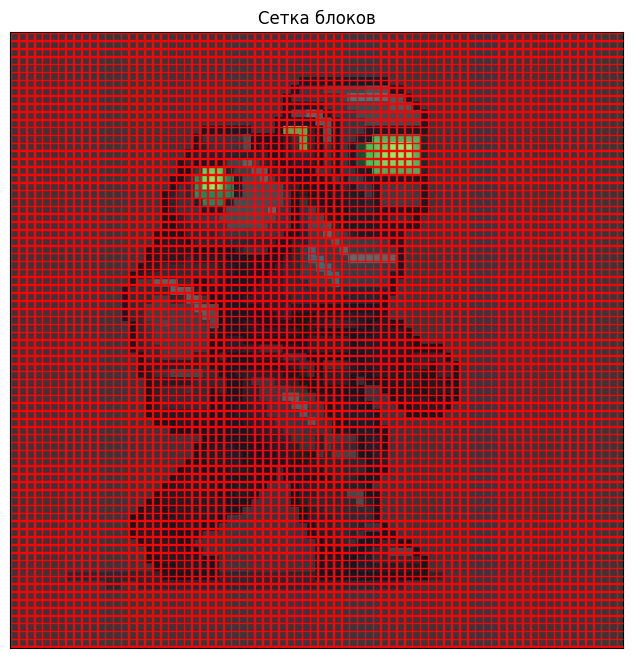

In [15]:
import matplotlib.patches as patches

def draw_grid(img, scale_x, scale_y):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img)

    h, w = img.shape[:2]
    
    # Рисуем вертикальные линии
    for x in range(0, w, scale_x):
        ax.add_patch(patches.Rectangle((x, 0), 1, h, edgecolor='red', facecolor='none', lw=1))
    
    # Рисуем горизонтальные линии
    for y in range(0, h, scale_y):
        ax.add_patch(patches.Rectangle((0, y), w, 1, edgecolor='red', facecolor='none', lw=1))

    ax.set_xticks([])
    ax.set_yticks([])
    plt.title("Сетка блоков")
    plt.show()

# Используем нашу обрезанную картинку и известный scale
draw_grid(cropped_img, scale_x,scale_y)

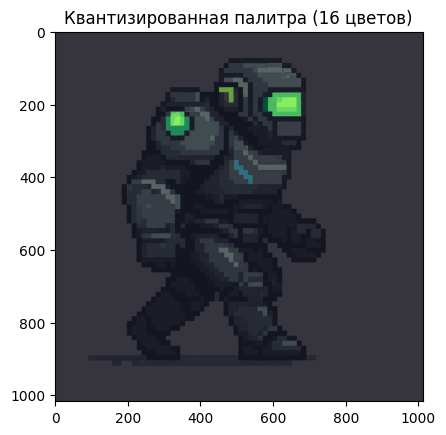

In [16]:
from sklearn.cluster import KMeans

def quantize_image(img, n_colors=16):
    h, w, c = img.shape
    pixels = img.reshape(-1, 3)
    kmeans = KMeans(n_clusters=n_colors, random_state=42).fit(pixels)
    new_colors = kmeans.cluster_centers_[kmeans.labels_]
    quantized_img = new_colors.reshape(h, w, 3).astype(np.uint8)
    return quantized_img

quantized_img = quantize_image(cropped_img, n_colors=16)
plt.imshow(quantized_img)
plt.title("Квантизированная палитра (16 цветов)")
plt.show()

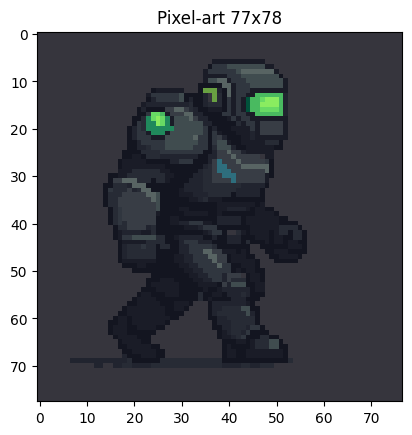

In [17]:
def block_downscale(img, scale_x, scale_y):
    h, w, _ = img.shape
    new_h, new_w = h // scale_y, w // scale_x
    result = np.zeros((new_h, new_w, 3), dtype=np.uint8)
    
    for by in range(new_h):
        for bx in range(new_w):
            block = img[by*scale_y:(by+1)*scale_y, bx*scale_x:(bx+1)*scale_x]
            colors, counts = np.unique(block.reshape(-1, 3), axis=0, return_counts=True)
            dominant_color = colors[np.argmax(counts)]
            result[by, bx] = dominant_color
    
    return result

pixel_art = block_downscale(quantized_img, scale_x, scale_y)
plt.imshow(pixel_art)
plt.title(f"Pixel-art {pixel_art.shape[1]}x{pixel_art.shape[0]}")
plt.show()


In [18]:
def pixel_art_pipeline(image_path, n_colors=16, have_manually_scale = False, expected_scale=40):
    img = np.array(Image.open(image_path).convert("RGB"))
    gray = to_gray(img)

    #Градиенты и профили
    gx, gy = sobel_gradients(gray)
    profile_x, profile_y = profile_from_gradients(gx, gy)

    #Оценка масштаба
    if have_manually_scale:
        scale_x = expected_scale
        scale_y = expected_scale
    else:
        scale_x = estimate_scale_fft(profile_x)
        scale_y = estimate_scale_fft(profile_y)
    print(f"Estimated scale: {scale_x} x {scale_y}")
    
    #Сдвиг сетки
    best_dx = find_best_offset(profile_x, scale_x)
    best_dy = find_best_offset(profile_y, scale_y)
    print(f"Best offset: x={best_dx}, y={best_dy}")

    #Обрезка изображения под сетку
    cropped_img = crop_to_scale(img, best_dx, best_dy, scale_x, scale_y)

    #уменьшение палитры
    quantized_img = quantize_image(cropped_img, n_colors=n_colors)

    #Блоковое приближение
    pixel_art = block_downscale(quantized_img, scale_x, scale_y)

    return pixel_art

Estimated scale: 4 x 4
Best offset: x=1, y=0


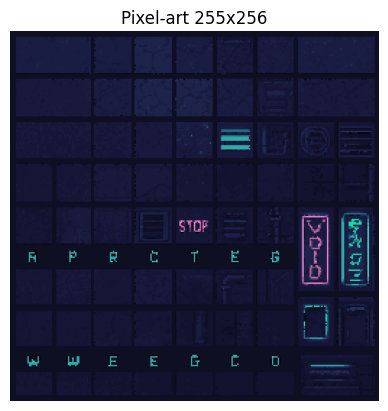

In [34]:
pixel_art_img = pixel_art_pipeline("assets_full.png",have_manually_scale = True, expected_scale=4)
plt.imshow(pixel_art_img)
plt.title(f"Pixel-art {pixel_art_img.shape[1]}x{pixel_art_img.shape[0]}")
plt.axis('off')
plt.show()

In [35]:
Image.fromarray(pixel_art_img).save("pixel_art_result.png")